In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

Load Datasets

In [2]:
X_train = torch.tensor(np.load("X_train.npy"), dtype=torch.float32)
y_train = torch.tensor(np.load("y_train.npy"), dtype=torch.float32).view(-1)

X_test = torch.tensor(np.load("X_test.npy"), dtype=torch.float32)
y_test = torch.tensor(np.load("y_test.npy"), dtype=torch.float32).view(-1)

Model

In [3]:
class ISNN1(nn.Module):
    def __init__(self, hidden_dim=10):
        super(ISNN1, self).__init__()

        self.softplus = nn.Softplus()
        self.sigmoid = nn.Sigmoid()

        # branches
        self.y_layer1 = nn.Linear(1, hidden_dim)
        self.y_layer2 = nn.Linear(hidden_dim, hidden_dim)

        self.z_layer1 = nn.Linear(1, hidden_dim)
        self.z_layer2 = nn.Linear(hidden_dim, hidden_dim)

        self.t_layer1 = nn.Linear(1, hidden_dim)
        self.t_layer2 = nn.Linear(hidden_dim, hidden_dim)

        self.x_layer1 = nn.Linear(1 + 3 * hidden_dim, hidden_dim)
        self.x_layer2 = nn.Linear(hidden_dim, hidden_dim)
        self.output_layer = nn.Linear(hidden_dim, 1)

    def forward(self, X):
        x = X[:, 0:1]
        y = X[:, 1:2]
        t = X[:, 2:3]
        z = X[:, 3:4]

        y = self.softplus(self.y_layer1(y))
        y = self.softplus(self.y_layer2(y))

        z = self.sigmoid(self.z_layer1(z))
        z = self.sigmoid(self.z_layer2(z))

        t = self.sigmoid(self.t_layer1(t))
        t = self.sigmoid(self.t_layer2(t))

        combined = torch.cat([x, y, z, t], dim=1)

        x = self.softplus(self.x_layer1(combined))
        x = self.softplus(self.x_layer2(x))

        return self.output_layer(x)


Training

In [4]:
def train_model(model, X_train, y_train, X_test, y_test, epochs=1000):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    loss_fn = nn.MSELoss()

    train_losses = []
    test_losses = []

    for epoch in range(epochs):
        model.train()

        optimizer.zero_grad()
        preds = model(X_train)

        loss = loss_fn(preds.view(-1), y_train)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            test_preds = model(X_test)
            test_loss = loss_fn(test_preds.view(-1), y_test)
            test_losses.append(test_loss.item())

        if epoch % 100 == 0:
            print(f"Epoch {epoch}: Train Loss = {loss.item():.4f}, Test Loss = {test_loss.item():.4f}")

    return train_losses, test_losses

Run Model

In [5]:
model = ISNN1(hidden_dim=10)

train_losses, test_losses = train_model(
    model, X_train, y_train, X_test, y_test, epochs=1000
)

Epoch 0: Train Loss = 6.1641, Test Loss = 5.8646
Epoch 100: Train Loss = 0.4654, Test Loss = 0.8696
Epoch 200: Train Loss = 0.4087, Test Loss = 0.8361
Epoch 300: Train Loss = 0.3703, Test Loss = 0.8101
Epoch 400: Train Loss = 0.3396, Test Loss = 0.7609
Epoch 500: Train Loss = 0.3056, Test Loss = 0.6885
Epoch 600: Train Loss = 0.2654, Test Loss = 0.5948
Epoch 700: Train Loss = 0.2225, Test Loss = 0.4747
Epoch 800: Train Loss = 0.1824, Test Loss = 0.3488
Epoch 900: Train Loss = 0.1479, Test Loss = 0.2467


Plot losses

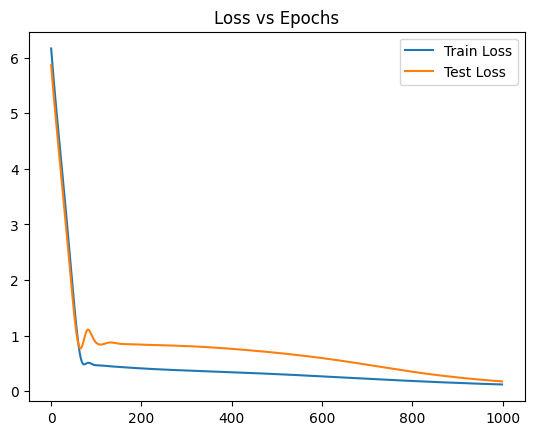

In [6]:
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.legend()
plt.title("Loss vs Epochs")
plt.show()

True Function

In [7]:
def true_function(v):
    return (
        np.exp(-0.5 * v)
        + np.log(1 + np.exp(0.4 * v))
        + np.tanh(v)
        + np.sin(v)
        - 0.4
    )

Behaviour Plot

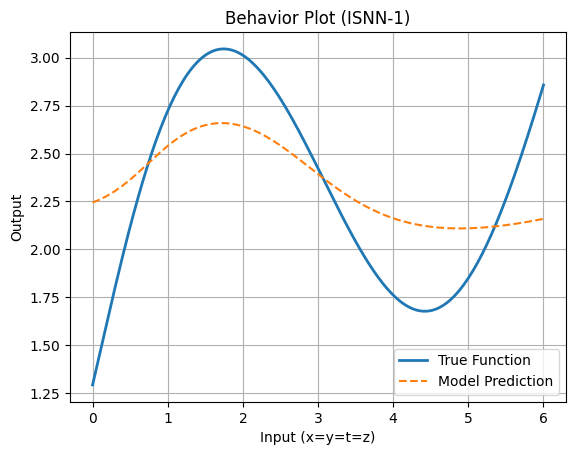

In [8]:
values = np.linspace(0, 6, 200)

X_plot = np.stack([values, values, values, values], axis=1)
X_plot_tensor = torch.tensor(X_plot, dtype=torch.float32)

model.eval()
with torch.no_grad():
    preds = model(X_plot_tensor).view(-1).numpy()

true_vals = true_function(values)

plt.plot(values, true_vals, label="True Function", linewidth=2)
plt.plot(values, preds, label="Model Prediction", linestyle="--")

plt.title("Behavior Plot (ISNN-1)")
plt.xlabel("Input (x=y=t=z)")
plt.ylabel("Output")

plt.legend()
plt.grid()
plt.show()